# ASR Correlation Analysis
This notebook explores the semantic backdoor attack experiment results to identify which factors (properties of the triggers such as Area, Circularity, etc.) correlate most strongly with the Attack Success Rate (ASR).

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the experiment results
df = pd.read_csv('merged_results_final.csv')
display(df.head())

,trigger_name,ASR,PBA_mIoU,PBA_mAcc,PBA_allAcc,CBA_mIoU,CBA_mAcc,CBA_allAcc,Area,Perimeter,...,LPIPS_Min,MSE_Max,MSE_Mean,MSE_Min,PSNR_Max,PSNR_Mean,PSNR_Min,SSIM_Max,SSIM_Mean,SSIM_Min
0,vertical-bars_vegetation-random,0.7687,0.6253,0.7172,0.9253,0.6377,0.7306,0.9383,1485,796.00,...,0.007248,45.729904,11.340929,5.114101,41.043111,38.156088,31.528801,0.993752,0.991636,0.990525
1,bullseye_vegetation-random,0.8696,0.6120,0.6925,0.9236,0.6363,0.7267,0.9378,620,178.51,...,0.005808,20.180581,4.927769,2.157927,44.790437,41.783337,35.081467,0.995786,0.993050,0.991637
2,fractal_inverted-road,0.7903,0.6210,0.7121,0.9254,0.6334,0.7262,0.9385,985,823.39,...,0.008877,52.812790,23.258629,3.564919,42.610307,34.859024,30.903413,0.994790,0.991329,0.990163
3,bullseye_road-random-opaque-50,0.0910,0.6201,0.7145,0.9215,0.6299,0.7255,0.9350,620,178.51,...,0.001087,3.725112,0.916182,0.546799,50.752524,48.911925,42.419410,0.997822,0.995819,0.992972
4,bus_trigger2,0.8959,0.6046,0.6824,0.9219,0.6354,0.7274,0.9382,2433,280.23,...,0.004881,53.470501,16.392907,10.907377,37.753600,36.142820,30.849661,0.993607,0.992268,0.991468


In [13]:
# Filter for numeric features only
numeric_df = df.select_dtypes(include=[np.number])

# Define the two groups of metrics based on column names
# We'll use case-insensitive matching to find the relevant columns
cols = numeric_df.columns.str.lower()

quality_keywords = ['lpips', 'psnr', 'ssim', 'mse', 'dba', 'pba']
geometric_keywords = ['entropy', 'perimeter', 'area', 'circularity', 'spectral', 'extent', 'solidity']

quality_cols = [c for c in numeric_df.columns if any(k in c.lower() for k in quality_keywords) and c != 'ASR']
geometric_cols = [c for c in numeric_df.columns if any(k in c.lower() for k in geometric_keywords) and c != 'ASR']

# Calculate Pearson correlation with ASR for Quality Metrics
print("--- Pearson Correlation with ASR: Image Quality & Performance Metrics ---")
if quality_cols:
    asr_corr_quality = numeric_df[quality_cols + ['ASR']].corr()['ASR'].drop('ASR')
    asr_corr_quality_sorted = asr_corr_quality.reindex(asr_corr_quality.abs().sort_values(ascending=False).index)
    print(asr_corr_quality_sorted)
else:
    print("No matching columns found.")

print("\n--- Pearson Correlation with ASR: Geometric & Texture Properties ---")
if geometric_cols:
    asr_corr_geometric = numeric_df[geometric_cols + ['ASR']].corr()['ASR'].drop('ASR')
    asr_corr_geometric_sorted = asr_corr_geometric.reindex(asr_corr_geometric.abs().sort_values(ascending=False).index)
    print(asr_corr_geometric_sorted)
else:
    print("No matching columns found.")


--- Pearson Correlation with ASR: Image Quality & Performance Metrics ---
LPIPS_Mean    0.556598
PSNR_Mean    -0.531356
PSNR_Max     -0.530124
PSNR_Min     -0.507063
SSIM_Mean    -0.498907
SSIM_Max     -0.480412
LPIPS_Max     0.467593
LPIPS_Min     0.450070
PBA_mAcc     -0.411592
PBA_mIoU     -0.352235
MSE_Max       0.347168
MSE_Min       0.339642
MSE_Mean      0.280248
SSIM_Min     -0.244975
PBA_allAcc    0.011216
Name: ASR, dtype: float64

--- Pearson Correlation with ASR: Geometric & Texture Properties ---
Color Entropy        0.177011
Perimeter           -0.163794
Circularity          0.108203
Spectral Centroid   -0.084683
Area                 0.030082
Spatial Entropy      0.019833
Name: ASR, dtype: float64


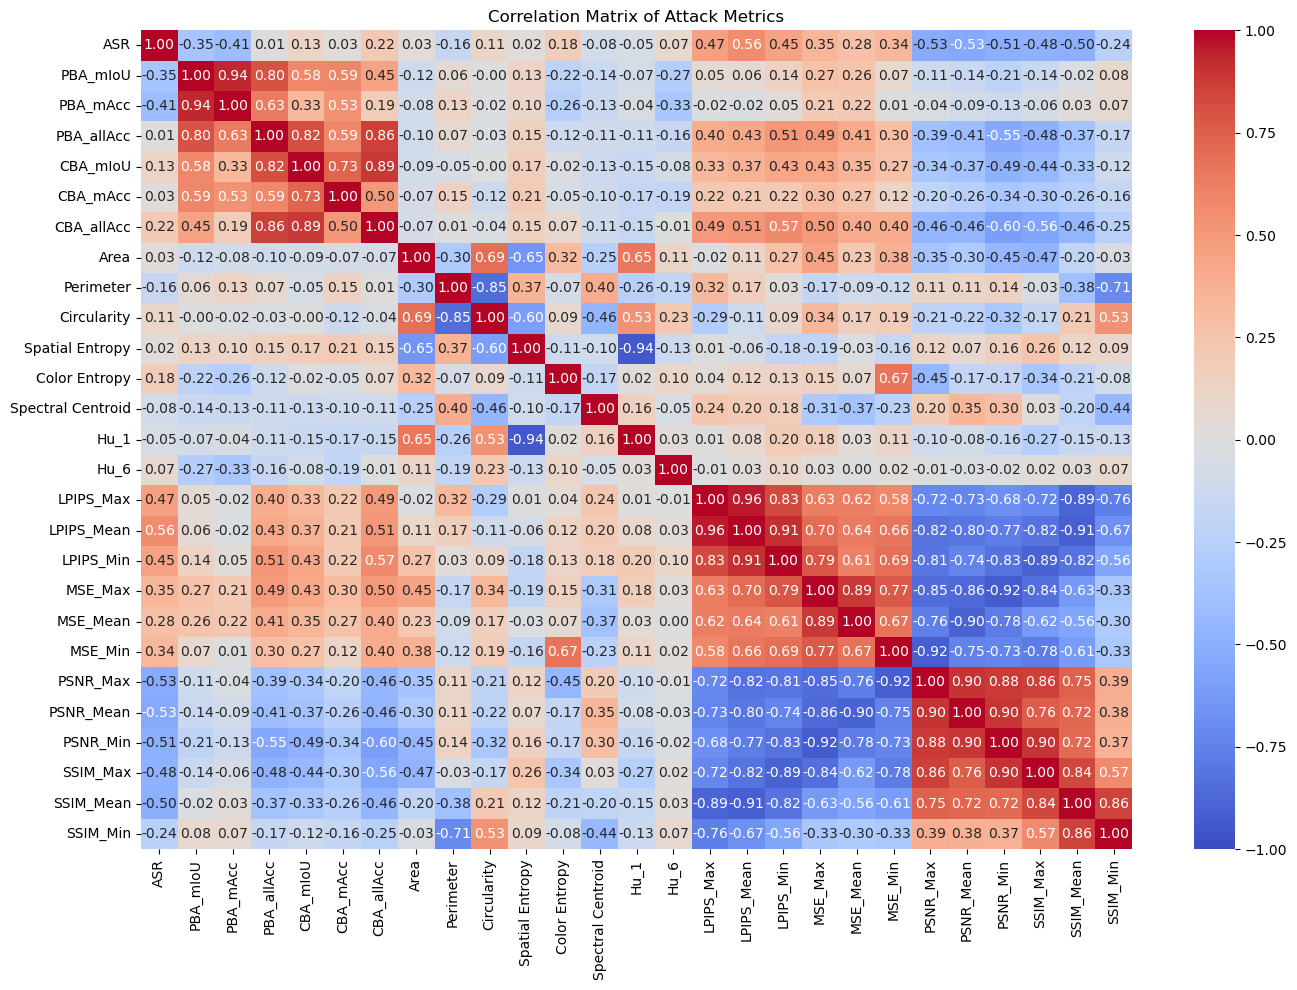

In [14]:
# Visualize the full correlation matrix
plt.figure(figsize=(14, 10))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Attack Metrics')
plt.tight_layout()
plt.show()

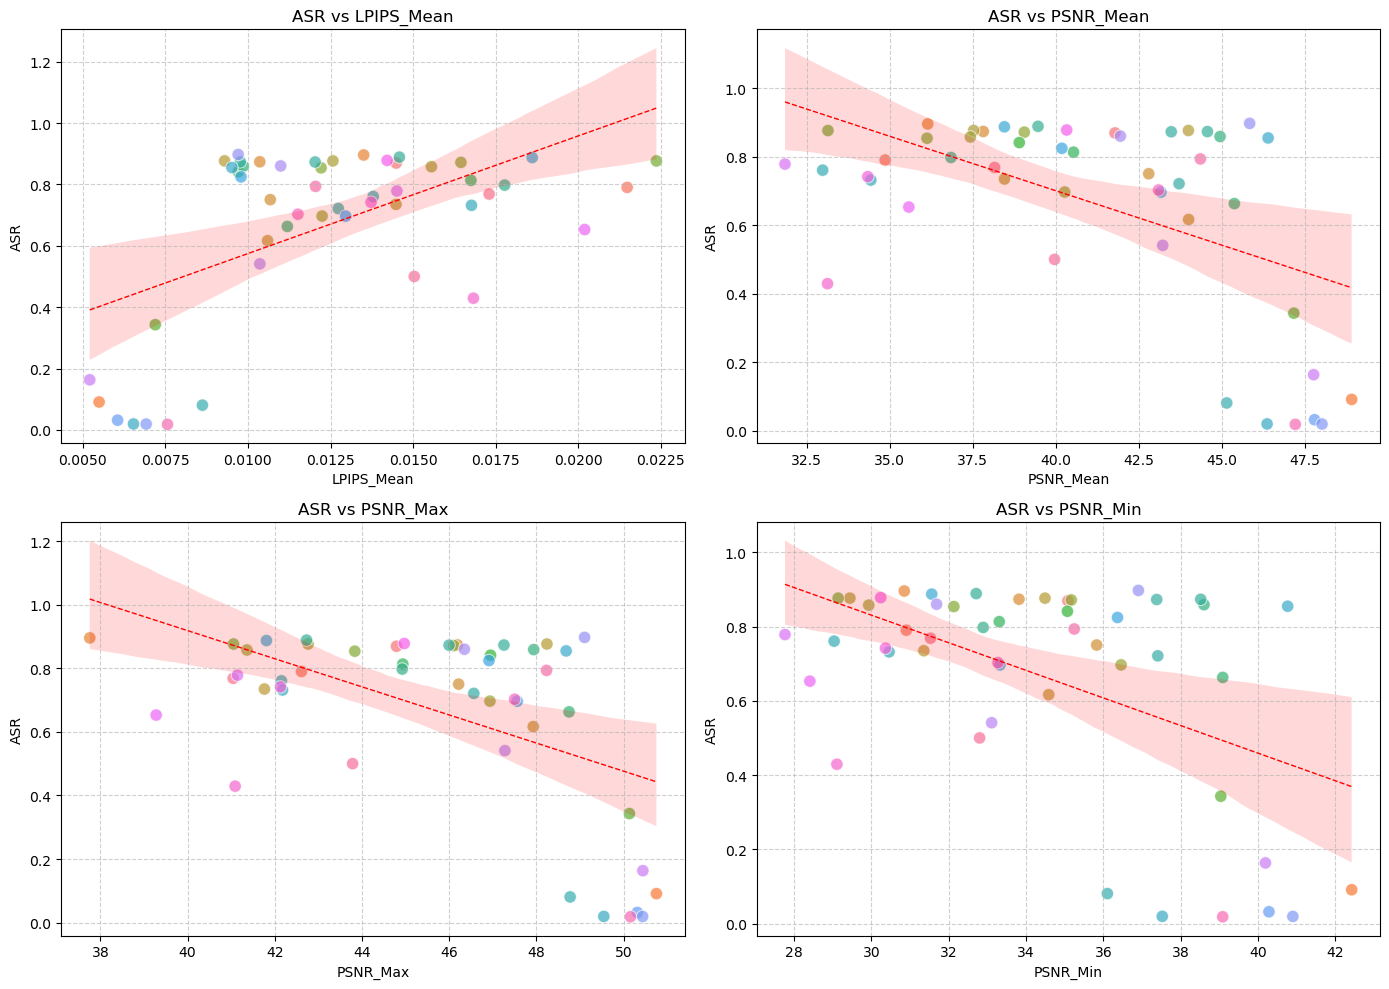

In [15]:
# Create scatter plots of ASR against the top 4 most correlated features
top_features = asr_correlations_sorted.head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    sns.scatterplot(data=df, x=feature, y='ASR', ax=axes[i], s=80, alpha=0.7, hue='trigger_name', legend=False)
    sns.regplot(data=df, x=feature, y='ASR', ax=axes[i], scatter=False, color='red', line_kws={"linewidth": 1, "linestyle": "--"})
    axes[i].set_title(f'ASR vs {feature}')
    axes[i].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Trigger Performance Summary
Extracting the `trigger_name`, `ASR`, `PBA_mIoU`, and `CBA_mIoU` to summarize the attack success rate alongside model performance metrics.

In [ ]:
# Extract specific columns
summary_cols = ['trigger_name', 'ASR', 'PBA_mIoU', 'CBA_mIoU']
performance_summary_df = df[summary_cols].copy()

# Sort by ASR in descending order to see the most effective triggers first
performance_summary_df = performance_summary_df.sort_values(by='ASR', ascending=False).reset_index(drop=True)

# Display the table
display(performance_summary_df)